In [2]:
%cd ..

/scratch/big/home/daawic/BSc-Thesis


In [4]:
import os
import torch
import matplotlib.pyplot as plt
import scienceplots
from torchvision.transforms import transforms
from project.models import EDMCallum
from project.util.device import get_available_acc
from project.util.plotting import plot_sample
from project.util.data import ReplayMemoryData
from project.util.metrics import MSE

In [5]:
plt.style.use(['science','no-latex', 'nature'])

In [6]:
PATH = os.path.join("..", "checkpoints", "diff", "Breakout.pt")
DATA = os.path.join("..", "checkpoints", "memory", "Breakout.pt")
IMAGES = 4

In [7]:
device = "cuda:9"

In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2),
    transforms.Normalize(0.5, 0.5),
])

In [9]:
data = ReplayMemoryData(
    memory=DATA,
    transform=transform,
    cap=500_000,
    train=False,
)

In [10]:
model = EDMCallum.from_checkpoint(PATH, device, U=20).to(device)

In [13]:
x = torch.zeros((IMAGES, 4, 88, 88), device=device)

perm = torch.randperm(500_000)[:IMAGES]

for i, img in enumerate(perm[:IMAGES]):
    x[i] = data[img].to(device)

mask = torch.ones_like(x, device=device)
mask[:, 2:] = 0

x_masked = x * mask
x_inpainted = model.inpaint(x, mask)

100%|██████████| 32/32 [00:36<00:00,  1.14s/it]


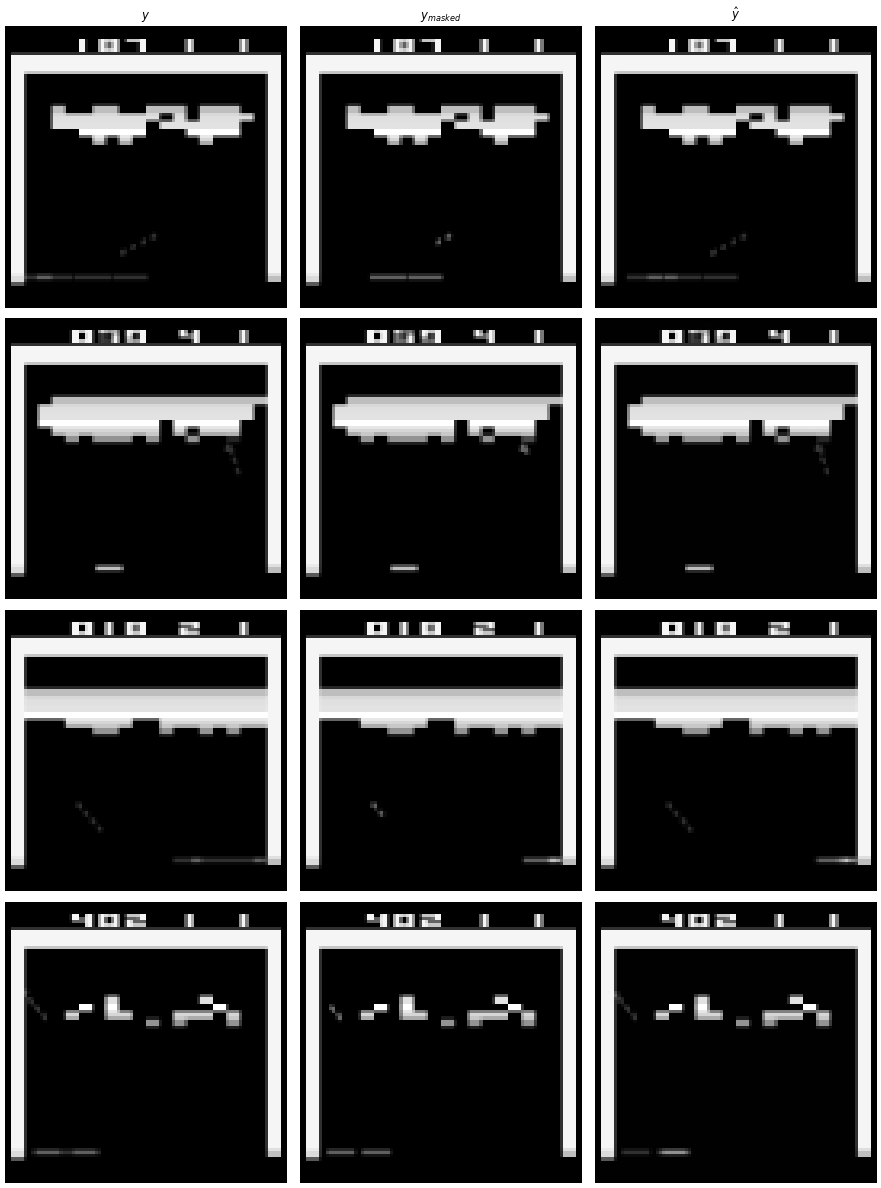

In [14]:
fig, axis = plt.subplots(IMAGES, 3, figsize=(9, 12))

for i in range(IMAGES):
    axis[i, 0].imshow(x[i].mean(dim=0).to("cpu"), cmap='grey')
    axis[i, 1].imshow(x_masked[i].mean(dim=0).to("cpu"), cmap='grey')
    axis[i, 2].imshow(x_inpainted[i].mean(dim=0).to("cpu"), cmap='grey')
    axis[i, 0].axis("off")
    axis[i, 1].axis("off")
    axis[i, 2].axis("off")
    if i == 0:
        axis[i, 0].set_title("$y$")
        axis[i, 1].set_title("$y_{masked}$")
        axis[i, 2].set_title("$\\hat y$")

plt.savefig("../results/inpainting/frames/examples.svg")
plt.tight_layout()
plt.show()